CASE STUDY 1: TELECOM CHURN PREDICTION

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8005 - loss: 0.4665 - val_accuracy: 0.8244 - val_loss: 0.4185
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8259 - loss: 0.4119 - val_accuracy: 0.8381 - val_loss: 0.3999
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8448 - loss: 0.3812 - val_accuracy: 0.8375 - val_loss: 0.3737
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8528 - loss: 0.3620 - val_accuracy: 0.8462 - val_loss: 0.3640
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8561 - loss: 0.3531 - val_accuracy: 0.8419 - val_loss: 0.3595
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8587 - loss: 0.3466 - val_accuracy: 0.8425 - val_loss: 0.3595
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8581 - loss: 0.3430 - val_accuracy: 0.8406 - val_loss: 0.3583
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8617 - loss: 0.3412 - val_accuracy: 0.8394 - val_

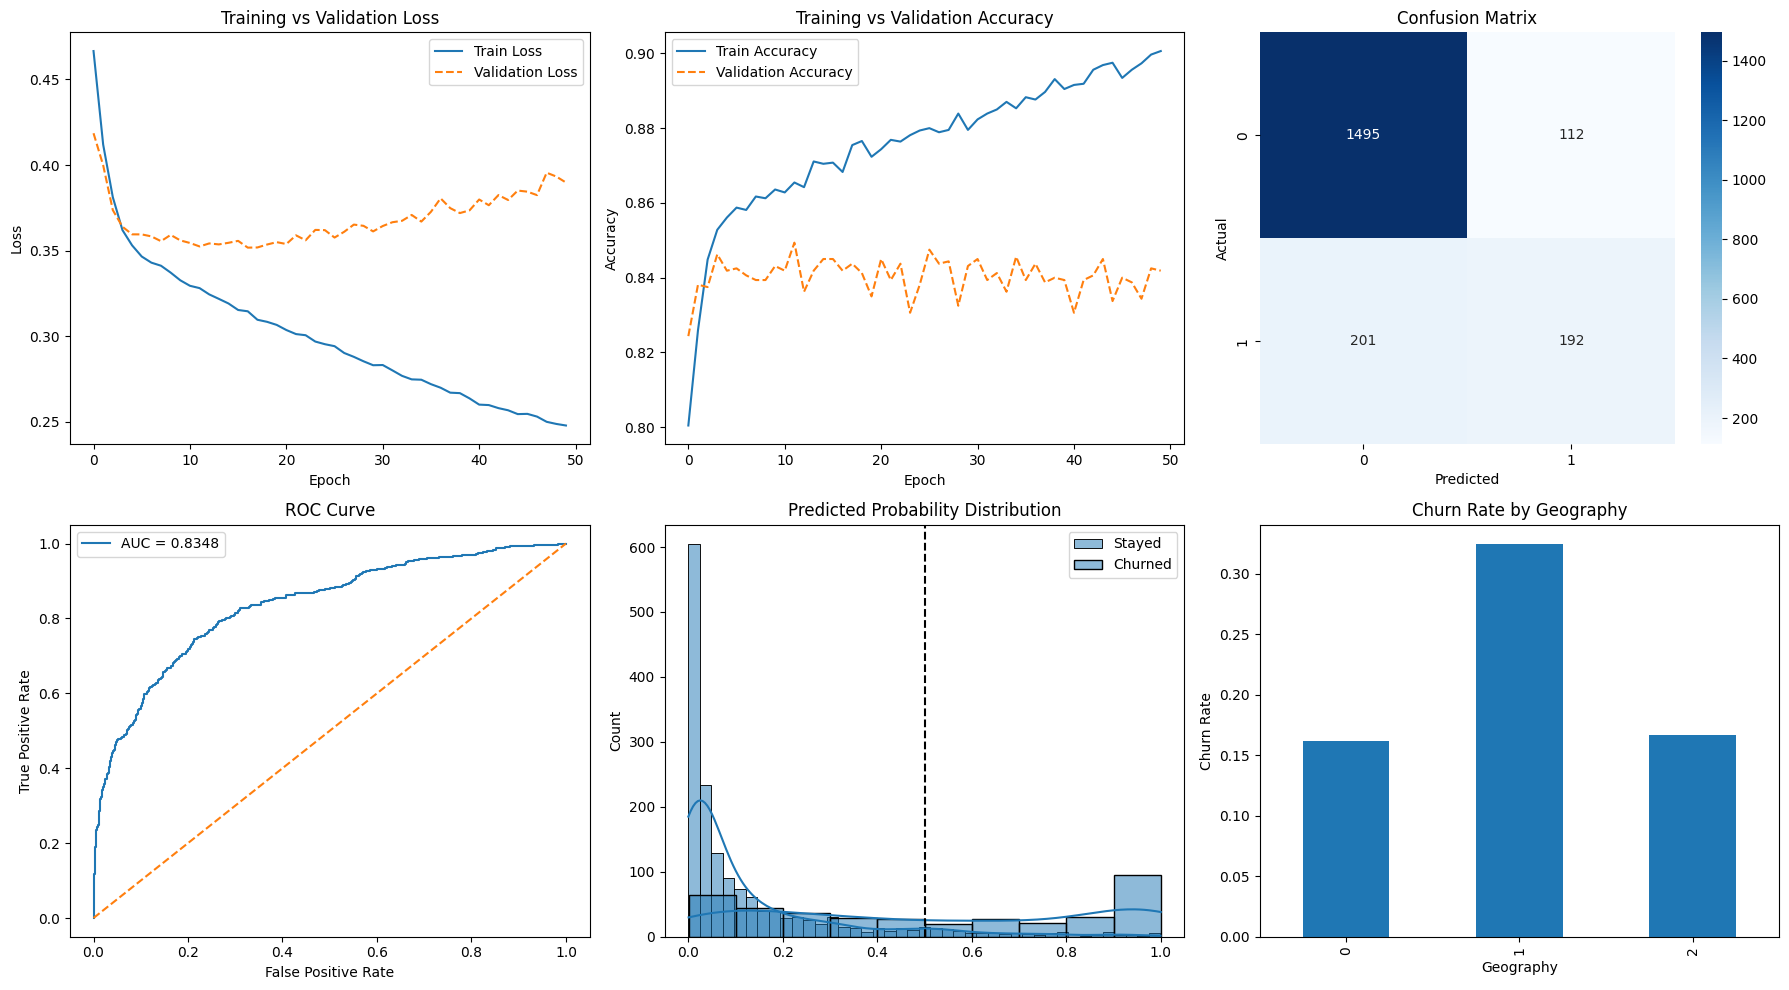

In [2]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load Dataset
data = pd.read_csv("Artificial_Neural_Network_Case_Study_data.csv")

# Preprocessing
data = data.dropna()

le = LabelEncoder()
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])

X = data.drop("Exited", axis=1)
y = data["Exited"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ANN Model
model = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train Model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluation
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

# Predictions
y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5)

# Create Subplots (Dashboard)
plt.figure(figsize=(18,10))

# 1. Loss Graph
plt.subplot(2,3,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], '--', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# 2. Accuracy Graph
plt.subplot(2,3,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], '--', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 3. Confusion Matrix (Heatmap)
plt.subplot(2,3,3)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# 4. ROC Curve
plt.subplot(2,3,4)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1], [0,1], '--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

# 5. Probability Distribution
plt.subplot(2,3,5)
sns.histplot(y_prob[y_test==0], color='blue', label='Stayed', kde=True)
sns.histplot(y_prob[y_test==1], color='red', label='Churned', kde=True)
plt.axvline(0.5, linestyle='--', color='black')
plt.title('Predicted Probability Distribution')
plt.legend()

# 6. Churn Rate (if column exists)
plt.subplot(2,3,6)
if 'Geography' in data.columns:
    churn_rate = data.groupby('Geography')['Exited'].mean()
    churn_rate.plot(kind='bar')
    plt.title('Churn Rate by Geography')
    plt.ylabel('Churn Rate')
else:
    plt.text(0.2,0.5,"No Category Column Found", fontsize=12)

plt.tight_layout()
plt.show()